## Part 2: Clinical Application

### Contents
Fill out this notebook as part 2 of your final project submission.

**You will have to complete the Code (Load Metadata & Compute Resting Heart Rate) and Project Write-up sections.**  

- [Code](#Code) is where you will implement some parts of the **pulse rate algorithm** you created and tested in Part 1 and already includes the starter code.
  - [Imports](#Imports) - These are the imports needed for Part 2 of the final project. 
    - [glob](https://docs.python.org/3/library/glob.html)
    - [os](https://docs.python.org/3/library/os.html)
    - [numpy](https://numpy.org/)
    - [pandas](https://pandas.pydata.org/)
  - [Load the Dataset](#Load-the-dataset)  
  - [Load Metadata](#Load-Metadata)
  - [Compute Resting Heart Rate](#Compute-Resting-Heart-Rate)
  - [Plot Resting Heart Rate vs. Age Group](#Plot-Resting-Heart-Rate-vs.-Age-Group)
- [Project Write-up](#Project-Write-Up) to describe the clinical significance you observe from the **pulse rate algorithm** applied to this dataset, what ways/information that could improve your results, and if we validated a trend known in the science community. 

### Dataset (CAST)

The data from this project comes from the [Cardiac Arrythmia Suppression Trial (CAST)](https://physionet.org/content/crisdb/1.0.0/), which was sponsored by the National Heart, Lung, and Blood Institute (NHLBI). CAST collected 24 hours of heart rate data from ECGs from people who have had a myocardial infarction (MI) within the past two years.<sup>1</sup> This data has been smoothed and resampled to more closely resemble PPG-derived pulse rate data from a wrist wearable.<sup>2</sup>

1. **CAST RR Interval Sub-Study Database Citation** - Stein PK, Domitrovich PP, Kleiger RE, Schechtman KB, Rottman JN. Clinical and demographic determinants of heart rate variability in patients post myocardial infarction: insights from the Cardiac Arrhythmia Suppression Trial (CAST). Clin Cardiol 23(3):187-94; 2000 (Mar)
2. **Physionet Citation** - Goldberger AL, Amaral LAN, Glass L, Hausdorff JM, Ivanov PCh, Mark RG, Mietus JE, Moody GB, Peng C-K, Stanley HE. PhysioBank, PhysioToolkit, and PhysioNet: Components of a New Research Resource for Complex Physiologic Signals (2003). Circulation. 101(23):e215-e220.

-----

### Code
#### Imports

When you implement the functions, you'll only need to you use the packages you've used in the classroom, like [Pandas](https://pandas.pydata.org/) and [Numpy](http://www.numpy.org/). These packages are imported for you here. We recommend you don't import other packages outside of the [Standard Library](https://docs.python.org/3/library/) , otherwise the grader might not be able to run your code.

In [1]:
import glob
import os

import numpy as np
import pandas as pd

#### Load the dataset

The dataset is stored as [.npz](https://docs.scipy.org/doc/numpy/reference/generated/numpy.savez.html) files. Each file contains roughly 24 hours of heart rate data in the 'hr' array sampled at 1Hz. The subject ID is the name of the file. You will use these files to compute resting heart rate.

Demographics metadata is stored in a file called 'metadata.csv'. This CSV has three columns, one for subject ID, age group, and sex. You will use this file to make the association between resting heart rate and age group for each gender.

Find the dataset in `../datasets/crisdb/`

In [20]:
hr_filenames = glob.glob('./datasets/crisdb/*.npz')

#### Load Metadata
Load the metadata file into a datastructure that allows for easy lookups from subject ID to age group and sex.

In [12]:
metadata_filename = './datasets/crisdb/metadata.csv'

# Load the metadata file into this variable.
with open(metadata_filename, 'r') as f:
    metadata = pd.read_csv(f)

In [14]:
metadata.head()

,subject,age,sex
0,e198a,20-24,Male
1,e198b,20-24,Male
2,e028b,30-34,Male
3,e028a,30-34,Male
4,e061b,30-34,Male


#### Compute Resting Heart Rate
For each subject we want to compute the resting heart rate while keeping track of which age group this subject belongs to. An easy, robust way to compute the resting heart rate is to use the lowest 5th percentile value in the heart rate timeseries.

In [34]:
import matplotlib.pyplot as plt

In [59]:
def AgeAndRHR(metadata, filename):
    """
    Synthesize heart-rate data & metadata by obtaining the resting heart rate (RHR).

    Args:
        metadata: a pandas dataframe containing subject's ID, age-group, and sex
        filename: a numpy array of heart-rate data

    Returns:
        age_group: a string of the subject's age-group
        sex: a string of the subject's sex
        rhr: a float of the subject's predicted RHR
    """

    # Load the heart rate timeseries
    hr_data = np.load(filename)['hr']
    
    # Compute the resting heart rate from the timeseries by finding the lowest 5th percentile value in hr_data
    rhr = np.percentile(hr_data, 5)

    # Find the subject ID from the filename.
    subject = filename.split('/')[-1].split('.')[0]

    # Find the age group for this subject in metadata.
    age_group = metadata[metadata.subject == subject].age.item()
    
    # Find the sex for this subject in metadata.
    sex = metadata[metadata.subject == subject].sex.item()

    return age_group, sex, rhr

df = pd.DataFrame(data=[AgeAndRHR(metadata, filename) for filename in hr_filenames],
                  columns=['age_group', 'sex', 'rhr'])

In [61]:
df.head()

,age_group,sex,rhr
0,50-54,Male,70.300009
1,50-54,Male,71.632525
2,65-69,Male,57.861801
3,50-54,Male,60.000000
4,55-59,Male,56.017647


#### Plot Resting Heart Rate vs. Age Group
We'll use [seaborn](https://seaborn.pydata.org/) to plot the relationship. Seaborn is a thin wrapper around matplotlib, which we've used extensively in this class, that enables higher-level statistical plots.

We will use [lineplot](https://seaborn.pydata.org/generated/seaborn.lineplot.html#seaborn.lineplot) to plot the mean of the resting heart rates for each age group along with the 95% confidence interval around the mean. Learn more about making plots that show uncertainty [here](https://seaborn.pydata.org/tutorial/relational.html#aggregation-and-representing-uncertainty).

Text(0.5, 1.0, 'RHR Trend')

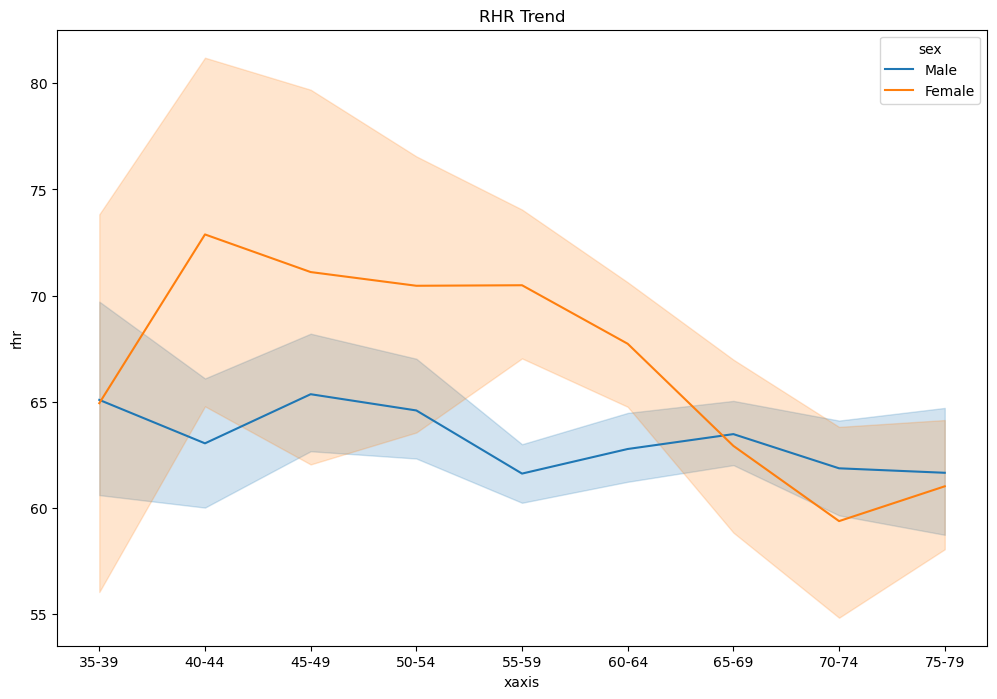

In [98]:
import seaborn as sns
from matplotlib import pyplot as plt

labels = sorted(np.unique(df.age_group))
df['xaxis'] = df.age_group.map(lambda x: labels.index(x)).astype('float')
plt.figure(figsize=(12, 8))
sns.lineplot(x='xaxis', y='rhr', hue='sex', data=df)
_ = plt.xticks(np.arange(len(labels)), labels)
plt.title('RHR Trend')

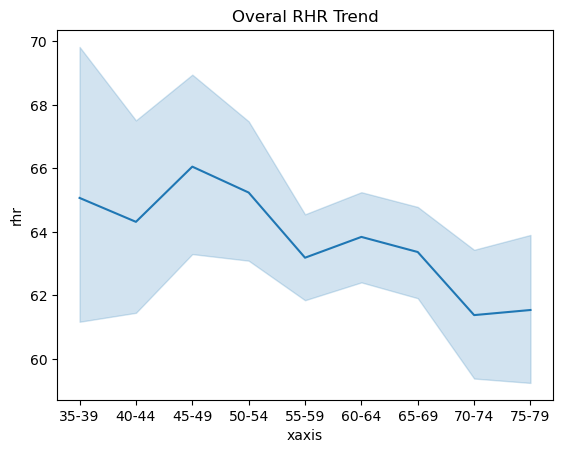

In [97]:
sns.lineplot(x='xaxis', y='rhr', data=df)
_ = plt.xticks(np.arange(len(labels)), labels)
plt.title('Overal RHR Trend');

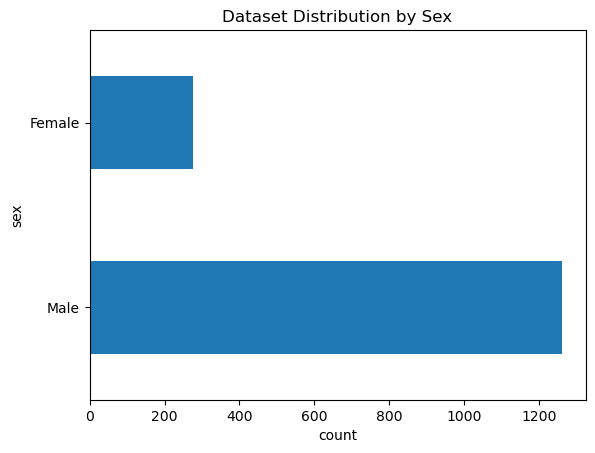

In [79]:
df.sex.value_counts().plot.barh(title='Dataset Distribution by Sex', xlabel='count');

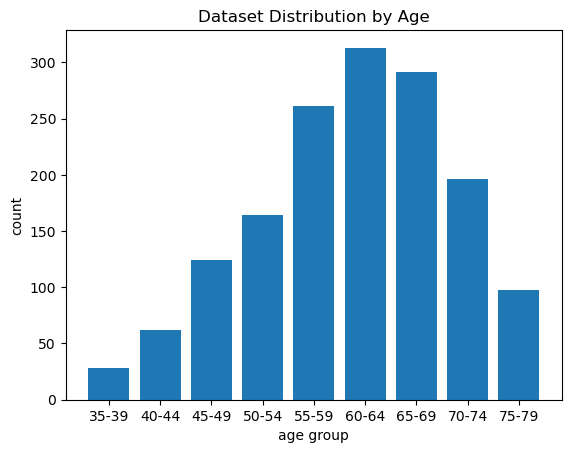

In [91]:
df_age_dist = df.age_group.value_counts().reset_index().sort_values('age_group')
plt.bar(df_age_dist['age_group'], df_age_dist['count'])
plt.ylabel('count')
plt.xlabel('age group')
plt.title('Dataset Distribution by Age');

### Clinical Conclusion
Answer the following prompts to draw a conclusion about the data.
> 1. For women, we see .... 
> 2. For men, we see ... 
> 3. In comparison to men, women's heart rate is .... 
> 4. What are some possible reasons for what we see in our data?
> 5. What else can we do or go and find to figure out what is really happening? How would that improve the results?
> 6. Did we validate the trend that average resting heart rate increases up until middle age and then decreases into old age? How?

Your write-up will go here...

1. For women, we see that the resting-heart-rate (RHR) increases from when they are aged 35-39 to 40-44. The increased value stays constant up to when they are aged 55-59, of when we see the decrease in the RHR trend. This lower RHR is then stays constant as they get older.
2. For men, we see fluctuations from the diagram above, but the general trend is that the RHR of men gets lower as they aged. We can see upsides, such as from age 40-44 to 45-49 and from 55-59 to 60-64, but there is no persistent increase observed, and vice versa.
3. In comparison to men, women's RHR is higher when they are at the age of 40-64. We can see that they get lower than men 65 onwards, but seemingly becoming the same as they reach 75-79.
4. As we can see from the dataset distribution above, there is a sex imbalance in the dataset, where women are underrepresented. This may cause what we see on the heart-rate diagram above, where women heart-rate trend is significantly different from the men's. The smaller the representation of a group in the dataset, the more likely the result/trend could vary from that group.
5. To figure out what is really happening, we could collect more data from female subjects to make it balanced. Not only that, we can also collect data with more metadata/features, such as subject's weight, to investigate what is the true factor driving the observed trend.
6. We have not fully validated the trend that the average resting heart rate increases up until the middle age and then decreases into old age. We do not have the age group of younger ages, so cannot really say if it is increasing into the middle ages of 30s and 40s. Even though we observed that in the female group, the RHR increased from the 30s to the 40s, the overall diagram above does not show that clearly. Part of it is due to the high uncertainty band around the age of 30s. Nevertheless, the trend that RHR decreases into old age is supported by the overall and per-group diagrams.